In [2]:
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar

# 1. Load result

In [4]:
efficient_mamba_predict_path = r'..\..\models\checkpoints\efficient_mamba\eval_results\predictions_full.csv'
efficient_transformer_predict_path = r'..\..\models\checkpoints\efficient_transformer\eval_results\predictions_full.csv'

In [7]:
mamba_result = pd.read_csv(efficient_mamba_predict_path)
transformer_result = pd.read_csv(efficient_transformer_predict_path)

In [9]:
print(mamba_result.head())

   True_ID  Pred_ID  True_Label  Pred_Label  Confidence  Correct
0        0        0  brush_hair  brush_hair      0.3878     True
1        0        5  brush_hair        walk      0.6244    False
2        0        0  brush_hair  brush_hair      0.2406     True
3        0        0  brush_hair  brush_hair      0.3559     True
4        0        0  brush_hair  brush_hair      0.7043     True


# 2. Testing

In [25]:
def compare_models_statistical(df1, df2, name1="Mamba", name2="Transformer", alpha=0.05, plot=True):
    print(f"STATISTICAL COMPARISON REPORT: {name1.upper()} vs {name2.upper()}")
    print("=" * 65)
    
    sns.set_theme(style="whitegrid")
    
    # ---------------------------------------------------------
    # ACCURACY TEST (McNemar's Test)
    # ---------------------------------------------------------
    print(f"\n[1] ACCURACY TEST (McNemar's Test)")

    yes_yes = ((df1['Correct'] == True) & (df2['Correct'] == True)).sum()
    yes_no  = ((df1['Correct'] == True) & (df2['Correct'] == False)).sum() # M1 wins
    no_yes  = ((df1['Correct'] == False) & (df2['Correct'] == True)).sum() # M2 wins
    no_no   = ((df1['Correct'] == False) & (df2['Correct'] == False)).sum()
    
    contingency_table = [[yes_yes, yes_no], 
                         [no_yes, no_no]]
    
    result_mcnemar = mcnemar(contingency_table, exact=(yes_no + no_yes < 25))
    p_value_acc = result_mcnemar.pvalue
    
    acc1 = df1['Correct'].mean()
    acc2 = df2['Correct'].mean()
    
    print(f"   - Accuracy: {name1}={acc1:.4f} | {name2}={acc2:.4f}")
    print(f"   - P-value : {p_value_acc:.4e}")
    
    if p_value_acc < alpha:
        winner = name1 if acc1 > acc2 else name2
        print(f"   CONCLUSION: STATISTICALLY SIGNIFICANT difference. {winner} is better.")
    else:
        print(f"   CONCLUSION: Difference is NOT statistically significant.")

    # ---------------------------------------------------------
    # CONFIDENCE TEST (Paired t-test)
    # ---------------------------------------------------------
    print(f"\n[2] CONFIDENCE TEST (Paired t-test)")
    
    conf1 = df1['Confidence']
    conf2 = df2['Confidence']

    t_stat, p_value_conf = stats.ttest_rel(conf1, conf2)
    
    mean_conf1 = conf1.mean()
    mean_conf2 = conf2.mean()
    
    print(f"   - Mean Confidence: {name1}={mean_conf1:.4f} | {name2}={mean_conf2:.4f}")
    print(f"   - T-statistic    : {t_stat:.4f}")
    print(f"   - P-value        : {p_value_conf:.4e}")
    
    if p_value_conf < alpha:
        confident_winner = name1 if mean_conf1 > mean_conf2 else name2
        print(f"   CONCLUSION: {confident_winner} is significantly more 'confident'.")
    else:
        print(f"   CONCLUSION: Comparable confidence levels.")
        
    print("=" * 65)

    # ---------------------------------------------------------
    # VISUALIZATIONS
    # ---------------------------------------------------------
    if plot:
        fig = plt.figure(figsize=(14, 6))
        
        # --- Contingency Heatmap (McNemar Visualization) ---
        ax1 = plt.subplot(1, 2, 1)
        matrix_data = pd.DataFrame(contingency_table, 
                                   index=[f"{name1}\nCorrect", f"{name1}\nWrong"],
                                   columns=[f"{name2}\nCorrect", f"{name2}\nWrong"])
        
        sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1, annot_kws={"size": 14})
        ax1.set_title("McNemar Matrix (Agreement vs Disagreement)", fontsize=12, fontweight='bold')
        
        ax1.text(0.5, 0.2, "Both Correct", ha='center', color='white', fontweight='bold')
        ax1.text(1.5, 0.2, f"{name1} Wins", ha='center', color='black', fontweight='bold')
        ax1.text(0.5, 1.2, f"{name2} Wins", ha='center', color='black', fontweight='bold')
        ax1.text(1.5, 1.2, "Both Wrong", ha='center', color='black', fontweight='bold')

        # --- Confidence Distributions (T-test Visualization) ---
        ax2 = plt.subplot(1, 2, 2)
        
        plot_data = pd.DataFrame({
            'Confidence': pd.concat([conf1, conf2]),
            'Model': [name1] * len(conf1) + [name2] * len(conf2)
        })

        sns.kdeplot(data=plot_data, x='Confidence', hue='Model', fill=True, alpha=0.3, linewidth=2, ax=ax2)
        
        ax2.axvline(mean_conf1, color='blue', linestyle='--', alpha=0.6, label=f'{name1} Mean')
        ax2.axvline(mean_conf2, color='orange', linestyle='--', alpha=0.6, label=f'{name2} Mean')
        
        ax2.set_title("Confidence Distribution (Density)", fontsize=12, fontweight='bold')
        ax2.set_xlim(0, 1)
        ax2.legend()

        plt.tight_layout()
        plt.show()

STATISTICAL COMPARISON REPORT: MAMBA vs TRANSFORMER

[1] ACCURACY TEST (McNemar's Test)
   - Accuracy: Mamba=0.7742 | Transformer=0.7880
   - P-value : 7.2772e-01
   CONCLUSION: Difference is NOT statistically significant.

[2] CONFIDENCE TEST (Paired t-test)
   - Mean Confidence: Mamba=0.5076 | Transformer=0.6381
   - T-statistic    : -14.1387
   - P-value        : 1.4494e-32
   CONCLUSION: Transformer is significantly more 'confident'.


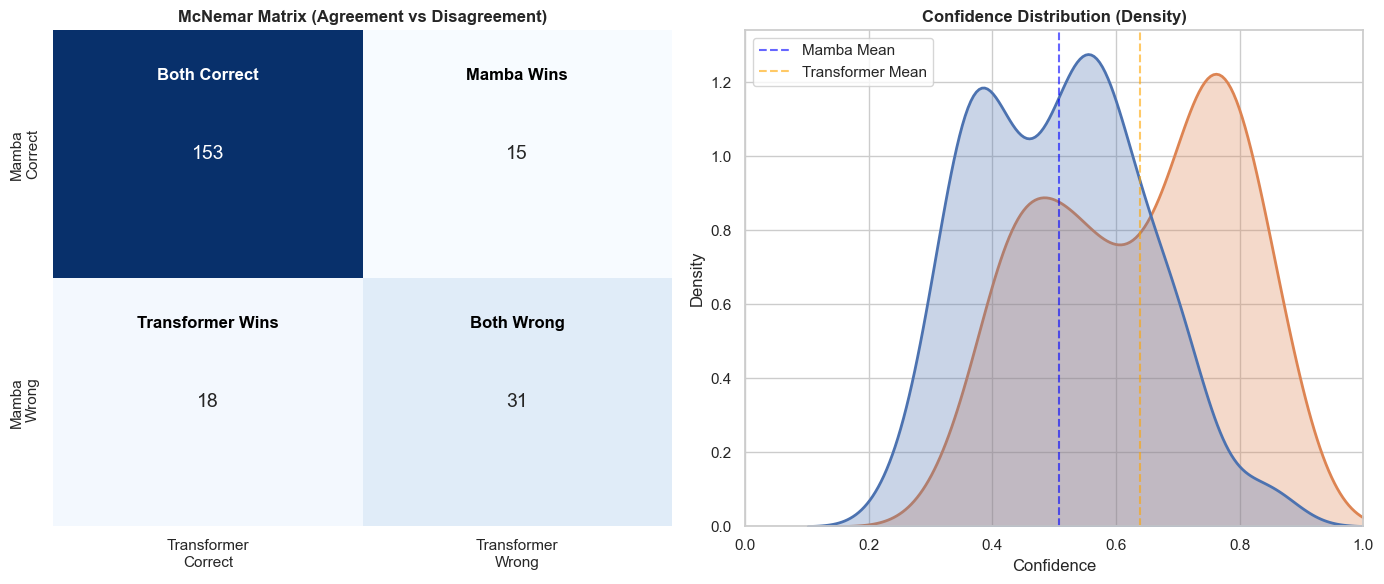

In [26]:
compare_models_statistical(mamba_result, transformer_result, "Mamba", "Transformer")

# 3. Conclusion

## 3.1. Reasons for testing approach
- **Accuracy** (`McNemar's Test`): Chosen because accuracy is binary (Correct/Incorrect); T-tests cannot handle binary paired data. 
- **Confidence** (`Paired T-Test`): Chosen to compare the average magnitude of certainty (continuous scores) across identical samples.

## 3.2. Insight
`Transformer` is significantly more `"decisive"` ($p < 0.05$). Despite similar accuracy, the `Transformer` assigns much higher confidence scores (`avg. 64%`) compared to Mamba (`avg. 51%`), which tends to be more "uncertain" or conservative in its predictions.